In [1]:
import torch

import quairkit as qkit
from quairkit import *
from quairkit.database.matrix import *
from quairkit.database.random import *
from quairkit.database.representation import *
from quairkit.qinfo import *


In [2]:
qkit.set_dtype("complex128")
print("dtype: ",qkit.get_dtype())

dtype:  torch.complex128


In [3]:
X = torch.tensor([[0, 1], [1, 0]])  # Pauli X matrix
Y = torch.tensor([[0, -1j], [1j, 0]])  # Pauli Y matrix
Z = torch.tensor([[1, 0], [0, -1]])  # Pauli Z matrix

print("The matrix form of Pauli X gate is\n", X, "\n")
print("The matrix form of Pauli Y gate is\n", Y, "\n")
print("The matrix form of Pauli Z gate is\n", Z)

The matrix form of Pauli X gate is
 tensor([[0, 1],
        [1, 0]]) 

The matrix form of Pauli Y gate is
 tensor([[0.+0.j, -0.-1.j],
        [0.+1.j, 0.+0.j]]) 

The matrix form of Pauli Z gate is
 tensor([[ 1,  0],
        [ 0, -1]])


In [4]:
sqrt_2 = torch.sqrt(torch.tensor(2))  # sqrt 2
isq2 = 1 / sqrt_2  # 1 / sqrt 2
# pi = torch.acos(torch.zeros(1)).item() * 2 # pi

H = isq2 * torch.tensor([[1, 1], [1, -1]])  # Hadamard gate
S = torch.tensor([[1, 0], [0, 1j]])  # Phase gate
T = torch.tensor([[1, 0], [0, torch.exp(torch.tensor(1j * torch.pi / 4))]])  # T gate

print("The matrix form of Hadamard gate is\n", H)
print("\nThe matrix form of Phase gate is\n", S)
print("\nThe matrix form of T gate is\n", T)

The matrix form of Hadamard gate is
 tensor([[ 0.7071,  0.7071],
        [ 0.7071, -0.7071]])

The matrix form of Phase gate is
 tensor([[1.+0.j, 0.+0.j],
        [0.+0.j, 0.+1.j]])

The matrix form of T gate is
 tensor([[1.0000+0.0000j, 0.0000+0.0000j],
        [0.0000+0.0000j, 0.7071+0.7071j]])


In [5]:
H_qkit = h()  # built-in Hadamard gate

print("The matrix form of built in Hadamard gate is\n", H_qkit)

The matrix form of built in Hadamard gate is
 tensor([[ 0.7071+0.j,  0.7071+0.j],
        [ 0.7071+0.j, -0.7071+0.j]])


In [6]:
theta = torch.round(2*torch.pi*torch.rand(1), decimals=3) # the parameter of Pauli rotation operators

Rx = rx(theta) # x-axis rotation gate
Ry = ry(theta) # y-axis rotation gate
Rz = rz(theta) # z-axis rotation gate

print(f'The matrix form of x-axis rotation gate with parameter {theta[0].numpy()} is\n{Rx}')
print(f'\nThe matrix form of y-axis rotation gate with parameter {theta[0].numpy()} is\n{Ry}')
print(f'\nThe matrix form of z-axis rotation gate with parameter {theta[0].numpy()} is\n{Rz}')


The matrix form of x-axis rotation gate with parameter 1.806 is
tensor([[0.6193+0.0000j, 0.0000-0.7852j],
        [0.0000-0.7852j, 0.6193+0.0000j]])

The matrix form of y-axis rotation gate with parameter 1.806 is
tensor([[ 0.6193+0.j, -0.7852+0.j],
        [ 0.7852+0.j,  0.6193+0.j]])

The matrix form of z-axis rotation gate with parameter 1.806 is
tensor([[0.6193-0.7852j, 0.0000+0.0000j],
        [0.0000+0.0000j, 0.6193+0.7852j]])


In [7]:
CNOT = cnot()  # controlled-NOT gate
CZ = cz()  # controlled-Z gate
SWAP = swap()  # swap gate

print("The matrix form of controlled-NOT gate is\n", CNOT, "\n")
print("The matrix form of controlled-Z gate is\n", CZ, "\n")
print("The matrix form of swap gate is\n", SWAP)

The matrix form of controlled-NOT gate is
 tensor([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
        [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]]) 

The matrix form of controlled-Z gate is
 tensor([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]]) 

The matrix form of swap gate is
 tensor([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]])


In [8]:
pure_state = random_state(num_qubits=1, rank=1) # random single-qubit pure state
mixed_state = random_state(num_qubits=1, rank=2) # random single-qubit mixed state
unitary = random_unitary(num_qubits=1) # random single-qubit unitary

pure_state_evo = pure_state.evolve(unitary)
mixed_state_evo = mixed_state.evolve(unitary)
print(f"pure output state after applying a unitary:\n {pure_state_evo.ket}\n")
print(f"mixed output state after applying a unitary:\n {mixed_state_evo.density_matrix}")


pure output state after applying a unitary:
 tensor([[ 0.1788-0.3628j],
        [-0.6024-0.6881j]])

mixed output state after applying a unitary:
 tensor([[0.6050-1.3878e-17j, 0.0214+2.1597e-01j],
        [0.0214-2.1597e-01j, 0.3950-1.3878e-17j]])


In [9]:
state = random_state(num_qubits=2)
unitary = random_unitary(num_qubits=1)

state_evo = state.evolve(unitary, sys_idx=[0])
print(f"state after applying a unitary on the first qubit:\n {state_evo.density_matrix}")


state after applying a unitary on the first qubit:
 tensor([[ 0.1085-1.2033e-18j,  0.0784+1.6611e-01j, -0.0690-1.2330e-01j,
         -0.0774-1.9251e-01j],
        [ 0.0784-1.6611e-01j,  0.3109+2.0219e-19j, -0.2385+1.6472e-02j,
         -0.3506-2.0591e-02j],
        [-0.0690+1.2330e-01j, -0.2385-1.6472e-02j,  0.1839+1.1234e-18j,
          0.2679+3.4373e-02j],
        [-0.0774+1.9251e-01j, -0.3506+2.0591e-02j,  0.2679-3.4373e-02j,
          0.3967-3.6681e-19j]])


In [10]:
state = random_state(num_qubits=1, size=5)  # 5 random single-qubit states (batched states)
unitary = random_unitary(num_qubits=1)
state_evo = state.evolve(unitary)
print(f"batched states after applying a unitary:\n {state_evo}")

batched states after applying a unitary:
 
-----------------------------------------------------
 Backend: default-pure
 System dimension: [2]
 System sequence: [0]
 Batch size: [5]

 # 0:
[-0.41+0.59j -0.64-0.26j]
 # 1:
[ 0.04-0.46j -0.03-0.89j]
 # 2:
[ 0.73+0.61j -0.3 -0.j  ]
 # 3:
[-0.44-0.02j  0.9 +0.03j]
 # 4:
[-0.6-0.42j -0.6-0.32j]
-----------------------------------------------------



In [11]:
state = random_state(num_qubits=1)
unitary = random_unitary(num_qubits=1, size=5) # 5 random single-qubit unitaries (batched unitaries)
state_evo = state.evolve(unitary)


print(f"state after applying batched unitaries:\n {state_evo}")

state after applying batched unitaries:
 
-----------------------------------------------------
 Backend: default-mixed
 System dimension: [2]
 System sequence: [0]
 Batch size: [5]

 # 0:
[[ 0.16-0.j  -0.11+0.2j]
 [-0.11-0.2j  0.84+0.j ]]
 # 1:
[[0.63+0.j   0.1 +0.38j]
 [0.1 -0.38j 0.37+0.j  ]]
 # 2:
[[0.86+0.j   0.13+0.14j]
 [0.13-0.14j 0.14+0.j  ]]
 # 3:
[[ 0.24+0.j   -0.3 -0.11j]
 [-0.3 +0.11j  0.76+0.j  ]]
 # 4:
[[0.65+0.j   0.38+0.06j]
 [0.38-0.06j 0.35-0.j  ]]
-----------------------------------------------------



the diagram of the quantum circuit:


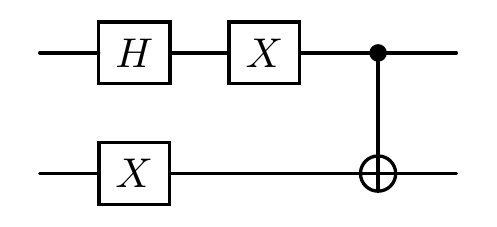

In [12]:

num_qubits = 2  # number of qubits

cir = Circuit(num_qubits)  # construct a quantum circuit
cir.h(0)  # Add Hadamard gate to qubit 0
cir.x([0, 1])  # Add X gate to qubit 0 and 1
cir.cx([0, 1])  # Add CNOT gate to qubit 0 and 1

print("the diagram of the quantum circuit:")
cir.plot()



In [13]:
state = random_state(num_qubits=2)
output_state = cir(state)  # run the circuit on a state

print(f"output state after applying a quantum circuit:\n {output_state}")



output state after applying a quantum circuit:
 
-----------------------------------------------------
 Backend: default-mixed
 System dimension: [2, 2]
 System sequence: [0, 1]
[[ 0.45+0.j    0.01+0.21j -0.18+0.12j -0.01-0.13j]
 [ 0.01-0.21j  0.29+0.j    0.16+0.11j -0.12+0.09j]
 [-0.18-0.12j  0.16-0.11j  0.16+0.j   -0.05+0.11j]
 [-0.01+0.13j -0.12-0.09j -0.05-0.11j  0.1 +0.j  ]]
-----------------------------------------------------



In [14]:
qkit.print_info()


---------VERSION---------
quairkit: 0.4.4
torch: 2.10.0+cu128
torch cuda: 12.8
numpy: 2.4.4
scipy: 1.17.1
matplotlib: 3.10.8
---------SYSTEM---------
Python version: 3.13.9
OS: Linux
OS version: #107-Ubuntu SMP PREEMPT_DYNAMIC Fri Mar 13 19:51:50 UTC 2026
---------DEVICE---------
CPU:  Intel(R) Core(TM) i7-4770 CPU @ 3.40GHz
GPU: (0) NVIDIA GeForce GTX 1650
